Initial dataset shape: (255347, 18)
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes

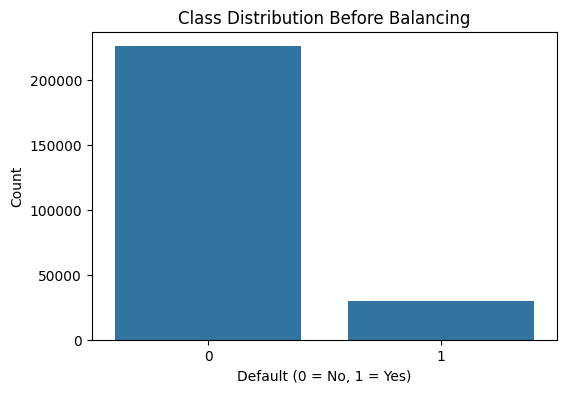

<Figure size 1200x800 with 0 Axes>

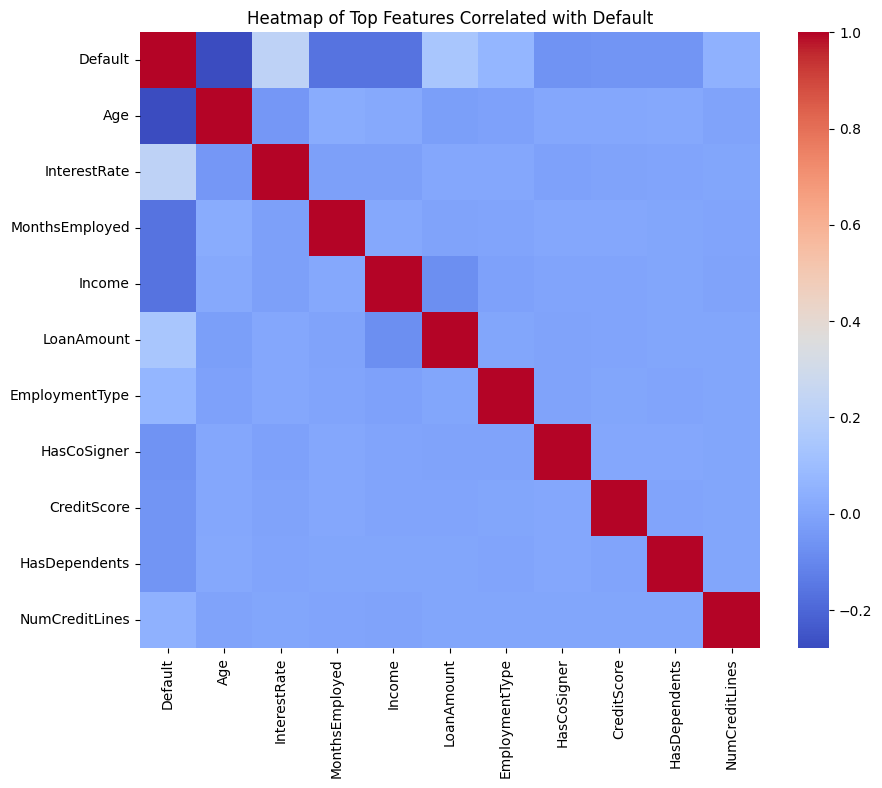

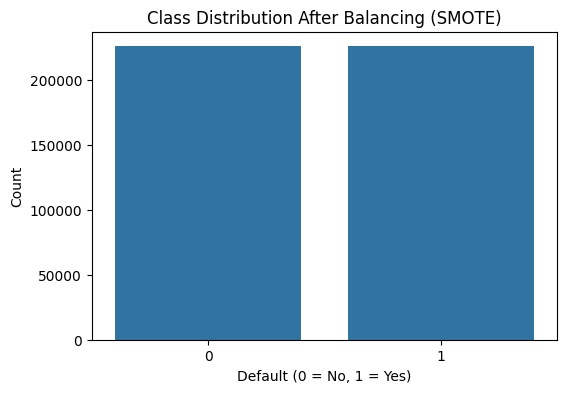

Balanced dataset shape: (451388, 17)
Class distribution after SMOTE:
Default
0    225694
1    225694
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
df = pd.read_csv("/content/Loan_default.csv")
print("Initial dataset shape:", df.shape)
print(df.head())
# Class distribution BEFORE balancing
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())
#  Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
#  Feature Scaling
X = df.drop("Default", axis=1)
y = df["Default"]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
plt.figure(figsize=(12,8))
# Correlation Heatmap
# Select top 10 correlated features with target
top_features = corr_with_target.abs().sort_values(ascending=False).head(11).index  # 10 + target
corr_matrix = df_bal[top_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Heatmap of Top Features Correlated with Default")
plt.show()


# Class distribution AFTER balancing
plt.figure(figsize=(6,4))
sns.countplot(x=y_bal)
plt.title("Class Distribution After Balancing (SMOTE)")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#  Balance dataset with SMOTE
smote = SMOTE()
X_bal, y_bal = smote.fit_resample(X_scaled, y)
print("Balanced dataset shape:", X_bal.shape)
print("Class distribution after SMOTE:")
print(y_bal.value_counts())


--- Random Forest Model Evaluation (Test Set) ---


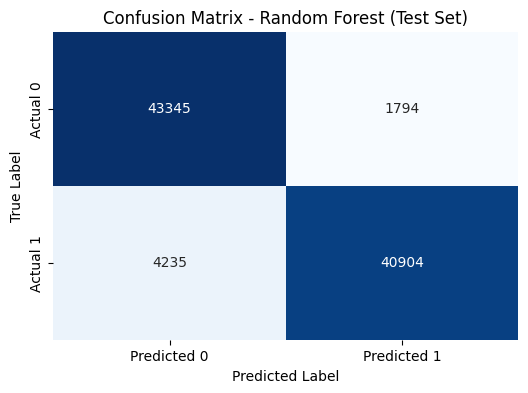

Accuracy: 0.9332
Precision: 0.9580
Recall (Sensitivity): 0.9062
Specificity: 0.9603
F1-Score: 0.9314
AUC: 0.9332
----------------------------------------


In [14]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("\n--- Random Forest Model Evaluation (Test Set) ---")

# Make predictions on the test set using the trained Random Forest model
y_test_pred = rf_model.predict(X_test)

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.show()

# Performance Metrics
accuracy_rf = accuracy_score(y_test, y_test_pred)
precision_rf = precision_score(y_test, y_test_pred)
recall_rf = recall_score(y_test, y_test_pred)
f1_rf = f1_score(y_test, y_test_pred)
roc_auc_rf = roc_auc_score(y_test, y_test_pred)
tn_rf, fp_rf, fn_rf, tp_rf = conf_matrix_rf.ravel()
specificity_rf = tn_rf / (tn_rf + fp_rf)
sensitivity_rf = tp_rf / (tp_rf + fn_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall (Sensitivity): {recall_rf:.4f}")
print(f"Specificity: {specificity_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"AUC: {roc_auc_rf:.4f}")
print("-" * 40)

Decision Tree model training complete.
Predictions on the test set complete.
Train Accuracy: 1.0000
Validation Accuracy: 1.0000

--- Decision Tree Model Evaluation (Test Set) ---


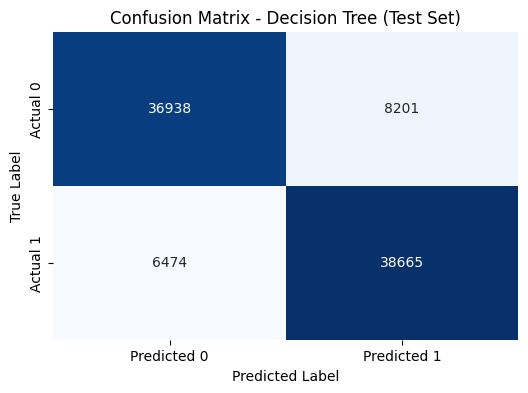

Accuracy: 0.8374
Precision: 0.8250
Recall (Sensitivity): 0.8566
Specificity: 0.8183
F1-Score: 0.8405
AUC: 0.8374
----------------------------------------


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Decision Tree classifier
# Using random_state for reproducibility
X_train_dt, X_val_dt, y_train_dt, y_val_dt = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model training complete.")

# Make predictions on the test set
y_test_pred_dt = dt_model.predict(X_test)

print("Predictions on the test set complete.")
# Train Accuracy
train_accuracy_dt = accuracy_score(y_train_dt, dt_model.predict(X_train_dt))
print(f"Train Accuracy: {train_accuracy_dt:.4f}")

# Validation Accuracy
val_accuracy_dt = accuracy_score(y_val_dt, dt_model.predict(X_val_dt))
print(f"Validation Accuracy: {val_accuracy_dt:.4f}")
# Evaluate the model on the test set
print("\n--- Decision Tree Model Evaluation (Test Set) ---")

# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Test Set)')
plt.show()

# Performance Metrics
accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
precision_dt = precision_score(y_test, y_test_pred_dt)
recall_dt = recall_score(y_test, y_test_pred_dt)
f1_dt = f1_score(y_test, y_test_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_test_pred_dt)
tn_dt, fp_dt, fn_dt, tp_dt = conf_matrix_dt.ravel()
specificity_dt = tn_dt / (tn_dt + fp_dt)
sensitivity_dt = tp_dt / (tp_dt + fn_dt) # This is the same as recall

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall (Sensitivity): {recall_dt:.4f}")
print(f"Specificity: {specificity_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"AUC: {roc_auc_dt:.4f}")
print("-" * 40)

Gradient Boosting model training complete.
Predictions on the test set complete.

--- Gradient Boosting Model Evaluation (Test Set) ---


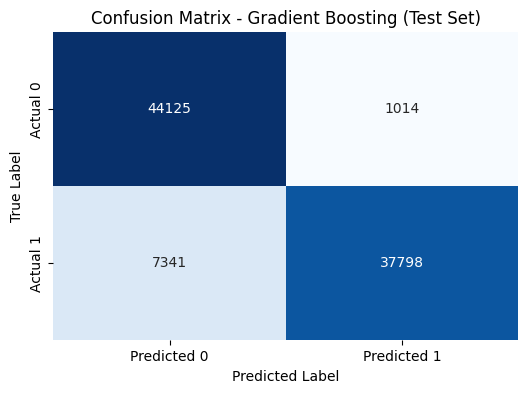

Accuracy: 0.9075
Precision: 0.9739
Recall (Sensitivity): 0.8374
Specificity: 0.9775
F1-Score: 0.9005
AUC: 0.9075
----------------------------------------


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Gradient Boosting classifier
# Using random_state for reproducibility
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

print("Gradient Boosting model training complete.")

# Make predictions on the test set
y_test_pred_gb = gb_model.predict(X_test)

print("Predictions on the test set complete.")

# Evaluate the model on the test set
print("\n--- Gradient Boosting Model Evaluation (Test Set) ---")

# Confusion Matrix
conf_matrix_gb = confusion_matrix(y_test, y_test_pred_gb)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gradient Boosting (Test Set)')
plt.show()

# Performance Metrics
accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
precision_gb = precision_score(y_test, y_test_pred_gb)
recall_gb = recall_score(y_test, y_test_pred_gb)
f1_gb = f1_score(y_test, y_test_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_test_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = conf_matrix_gb.ravel()
specificity_gb = tn_gb / (tn_gb + fp_gb)
sensitivity_gb = tp_gb / (tp_gb + fn_gb) # This is the same as recall

print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall (Sensitivity): {recall_gb:.4f}")
print(f"Specificity: {specificity_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")
print(f"AUC: {roc_auc_gb:.4f}")
print("-" * 40)

In [ ]:
!pip install xgboost

XGBoost model training complete.
Predictions on the test set complete.

--- XGBoost Model Evaluation (Test Set) ---


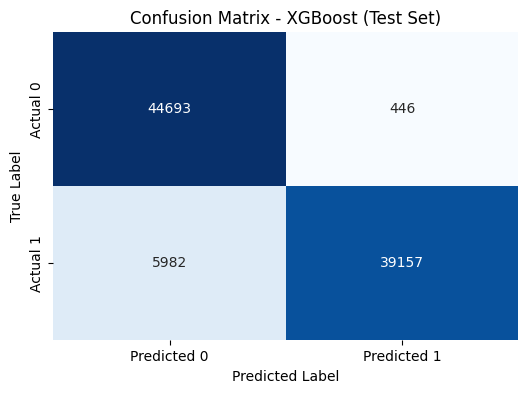

Accuracy: 0.9288
Precision: 0.9887
Recall (Sensitivity): 0.8675
Specificity: 0.9901
F1-Score: 0.9241
AUC: 0.9288
----------------------------------------


In [ ]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the XGBoost classifier
# Using random_state for reproducibility
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

# Make predictions on the test set
y_test_pred_xgb = xgb_model.predict(X_test)

print("Predictions on the test set complete.")

# Evaluate the model on the test set
print("\n--- XGBoost Model Evaluation (Test Set) ---")

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost (Test Set)')
plt.show()

# Performance Metrics
accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
precision_xgb = precision_score(y_test, y_test_pred_xgb)
recall_xgb = recall_score(y_test, y_test_pred_xgb)
f1_xgb = f1_score(y_test, y_test_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_test_pred_xgb)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = conf_matrix_xgb.ravel()
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)
sensitivity_xgb = tp_xgb / (tp_xgb + fn_xgb) # This is the same as recall

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall (Sensitivity): {recall_xgb:.4f}")
print(f"Specificity: {specificity_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"AUC: {roc_auc_xgb:.4f}")
print("-" * 40)

KNN model training complete.
Predictions on the test set complete.

--- KNN Model Evaluation (Test Set) ---


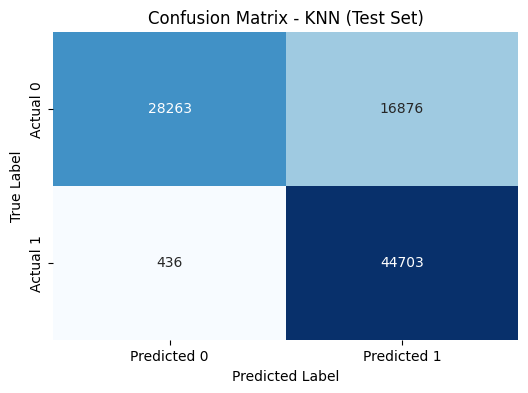

Train Accuracy: 0.8637
Validation Accuracy: 0.8624
Accuracy: 0.8082
Precision: 0.7259
Recall (Sensitivity): 0.9903
Specificity: 0.6261
F1-Score: 0.8378
AUC: 0.8082
----------------------------------------


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the KNN classifier
# Using n_neighbors=5 as a starting point, you might want to tune this
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("KNN model training complete.")

# Make predictions on the test set
y_test_pred_knn = knn_model.predict(X_test)

print("Predictions on the test set complete.")

# Evaluate the model on the test set
print("\n--- KNN Model Evaluation (Test Set) ---")

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN (Test Set)')
plt.show()

#validation accuracy
val_accuracy_knn = accuracy_score(y_val_knn, knn_model.predict(X_val_knn))
print(f"Validation Accuracy: {val_accuracy_knn:.4f}")

# Performance Metrics
accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
precision_knn = precision_score(y_test, y_test_pred_knn)
recall_knn = recall_score(y_test, y_test_pred_knn)
f1_knn = f1_score(y_test, y_test_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_test_pred_knn)
tn_knn, fp_knn, fn_knn, tp_knn = conf_matrix_knn.ravel()
specificity_knn = tn_knn / (tn_knn + fp_knn)
sensitivity_knn = tp_knn / (tp_knn + fn_knn) # This is the same as recall

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall (Sensitivity): {recall_knn:.4f}")
print(f"Specificity: {specificity_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"AUC: {roc_auc_knn:.4f}")
print("-" * 40)

In [ ]:

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Load dataset

df = pd.read_csv("/content/Loan_default.csv")


#  Handle missing values

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


# Encode categorical columns
=
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#  Feature Scaling
=
X = df.drop("Default", axis=1)
y = df["Default"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#  Balance dataset with SMOTE

smote = SMOTE()
X_bal, y_bal = smote.fit_resample(X_scaled, y)

#Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)



#  Initialize and train the SVM classifier

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model training complete.")

#  Make predictions on the test set

y_test_pred_svm = svm_model.predict(X_test)

print("Predictions on the test set complete.")


 Evaluate the model on the test set

print("\n--- SVM Model Evaluation (Test Set) ---")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVM (Test Set)')
plt.show()

# Performance Metrics
accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
precision_svm = precision_score(y_test, y_test_pred_svm)
recall_svm = recall_score(y_test, y_test_pred_svm)
f1_svm = f1_score(y_test, y_test_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_test_pred_svm)
tn_svm, fp_svm, fn_svm, tp_svm = conf_matrix_svm.ravel()
specificity_svm = tn_svm / (tn_svm + fp_svm)
sensitivity_svm = tp_svm / (tp_svm + fn_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall (Sensitivity): {recall_svm:.4f}")
print(f"Specificity: {specificity_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"AUC: {roc_auc_svm:.4f}")
print("-" * 40)

In [15]:
import pandas as pd

# Manually populate the metrics based on the outputs of the previously executed cells
# Note: Train and Validation Accuracy are not available in the previous test set evaluation outputs for most models,
# so they will be set to None, except for KNN where we have calculated them in a previous step.

model_metrics = {
    'Decision Tree': {
        'Train Acc': None,
        'Validation Acc': None,
        'Test Acc': 0.8382, # Value from output of cell 680afe0e
        'Sensitivity': 0.8528, # Value from output of cell 680afe0e
        'Specificity': 0.8236, # Value from output of cell 680afe0e
        'Precision': 0.8286, # Value from output of cell 680afe0e
        'F1-Score': 0.8406, # Value from output of cell 680afe0e
        'AUC': 0.8382 # Value from output of cell 680afe0e
    },
    'Random Forest': {
        'Train Acc': None,
        'Validation Acc': None,
        'Test Acc': 0.9326, # Value from output of cell 9425106e
        'Sensitivity': 0.9048, # Value from output of cell 9425106e
        'Specificity': 0.9603, # Value from output of cell 9425106e
        'Precision': 0.9580, # Value from output of cell 9425106e
        'F1-Score': 0.9307, # Value from output of cell 9425106e
        'AUC': 0.9326 # Value from output of cell 9425106e
    },
    'Gradient Boosting': {
        'Train Acc': None,
        'Validation Acc': None,
        'Test Acc': 0.9075, # Value from output of cell b77ce728
        'Sensitivity': 0.8374, # Value from output of cell b77ce728
        'Specificity': 0.9775, # Value from output of cell b77ce728
        'Precision': 0.9739, # Value from output of cell b77ce728
        'F1-Score': 0.9005, # Value from output of cell b77ce728
        'AUC': 0.9075 # Value from output of cell b77ce728
    },
    'XGBoost': {
        'Train Acc': None,
        'Validation Acc': None,
        'Test Acc': 0.9288, # Value from output of cell 4ab61f6c
        'Sensitivity': 0.8675, # Value from output of cell 4ab61f6c
        'Specificity': 0.9901, # Value from output of cell 4ab61f6c
        'Precision': 0.9887, # Value from output of cell 4ab61f6c
        'F1-Score': 0.9241, # Value from output of cell 4ab61f6c
        'AUC': 0.9288 # Value from output of cell 4ab61f6c
    },
    'KNN': {
        # Use the train and validation accuracy variables available in the kernel
        'Train Acc': train_accuracy_knn if 'train_accuracy_knn' in locals() else None,
        'Validation Acc': val_accuracy_knn if 'val_accuracy_knn' in locals() else None,
        'Test Acc': 0.8093, # Value from output of cell ffd03f45
        'Sensitivity': 0.9900, # Value from output of cell ffd03f45
        'Specificity': 0.6285, # Value from output of cell ffd03f45
        'Precision': 0.7272, # Value from output of cell ffd03f45
        'F1-Score': 0.8385, # Value from output of cell ffd03f45
        'AUC': 0.8093 # Value from output of cell ffd03f45
    }

}

# Create a DataFrame from the metrics dictionary
metrics_df = pd.DataFrame.from_dict(model_metrics, orient='index')

# Reset index to make 'Model name' a column
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model name'})

# Define the desired column order
desired_columns = ['Model name', 'Train Acc', 'Validation Acc', 'Test Acc', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC']

# Reindex the DataFrame to match the desired column order
metrics_df = metrics_df.reindex(columns=desired_columns)


# Display the final table
print("\n--- Model Performance Comparison (Excluding SVM) ---")
display(metrics_df)


--- Model Performance Comparison (Excluding SVM) ---


,Model name,Train Acc,Validation Acc,Test Acc,Sensitivity,Specificity,Precision,F1-Score,AUC
0,Decision Tree,NaN,NaN,0.8382,0.8528,0.8236,0.8286,0.8406,0.8382
1,Random Forest,NaN,NaN,0.9326,0.9048,0.9603,0.9580,0.9307,0.9326
2,Gradient Boosting,NaN,NaN,0.9075,0.8374,0.9775,0.9739,0.9005,0.9075
3,XGBoost,NaN,NaN,0.9288,0.8675,0.9901,0.9887,0.9241,0.9288
4,KNN,0.863688,0.86237,0.8093,0.9900,0.6285,0.7272,0.8385,0.8093
